In [25]:
# DRIFTED DATA 

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [26]:
data = np.loadtxt("Talin_fragment.txt", skiprows=1)
t = data[:, 0]
x = data[:, 1]

peaks = [38.40405789, 60.47746683]
len(t)

7818824

c:\Users\bulga\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
c:\Users\bulga\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


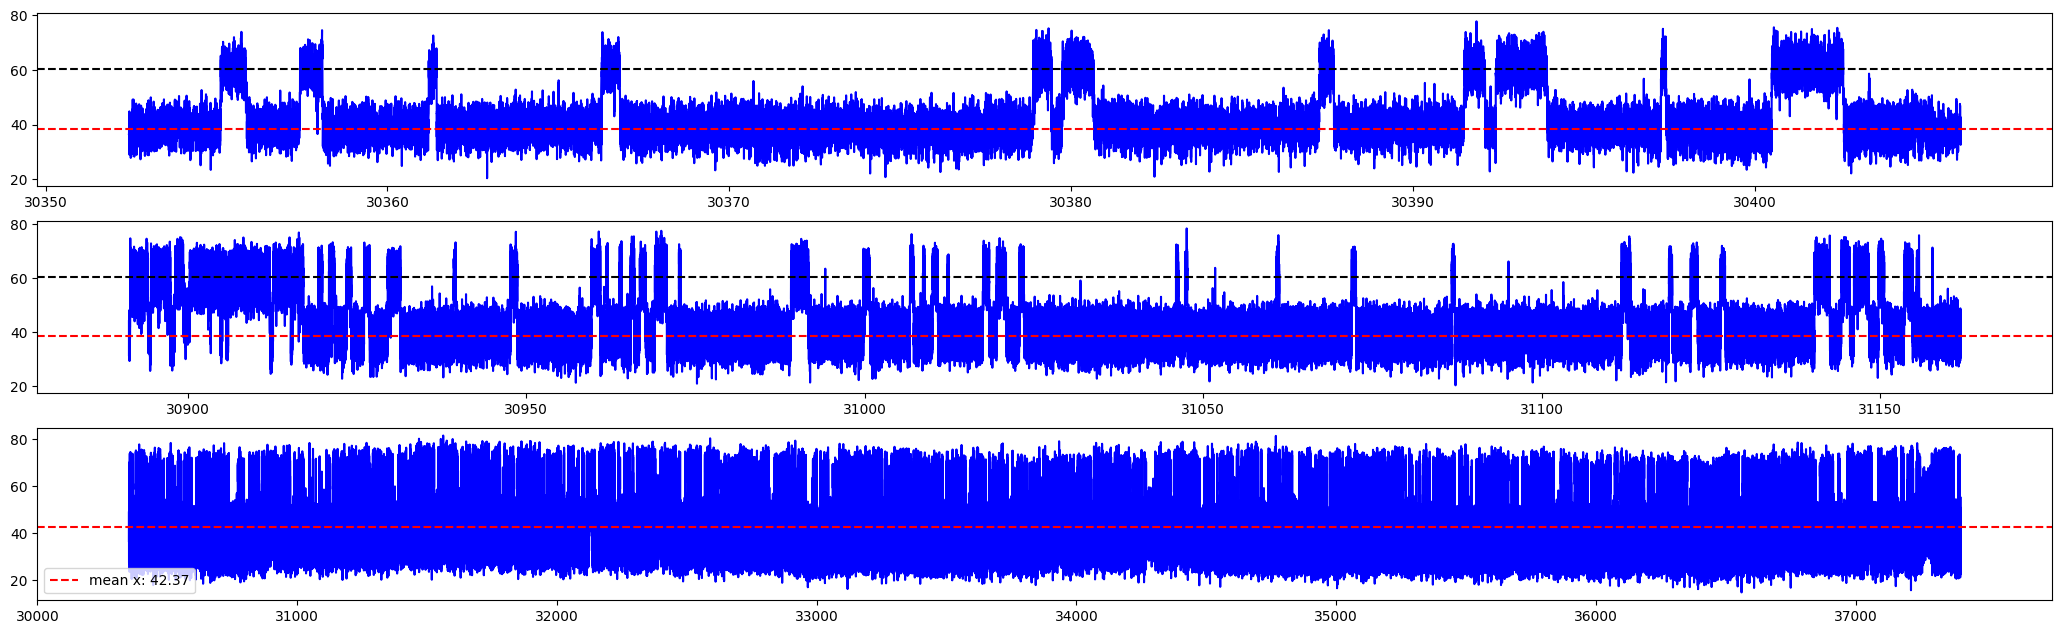

In [27]:

# Plot
plt.figure(figsize=(26, 13))

q =5 
# Primo subplot
plt.subplot(q, 1,  1)
plt.plot(t[0:60_000], x[0:60_000], color='blue')
plt.axhline(y=peaks[0], color='red', linestyle='--')
plt.axhline(y=peaks[1], color='black', linestyle='--')

plt.subplot(q, 1,  2)
plt.plot(t[600_000:900_000], x[600_000:900_000], color='blue')
plt.axhline(y=peaks[0], color='red', linestyle='--')
plt.axhline(y=peaks[1], color='black', linestyle='--')

plt.subplot(q, 1,  3)
plt.plot(t, x, color='blue')
plt.axhline(y=np.mean(x), color='red', linestyle='--', label = 'mean x: {:.2f}'.format(np.mean(x)))
plt.legend()


c:\Users\bulga\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\bulga\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


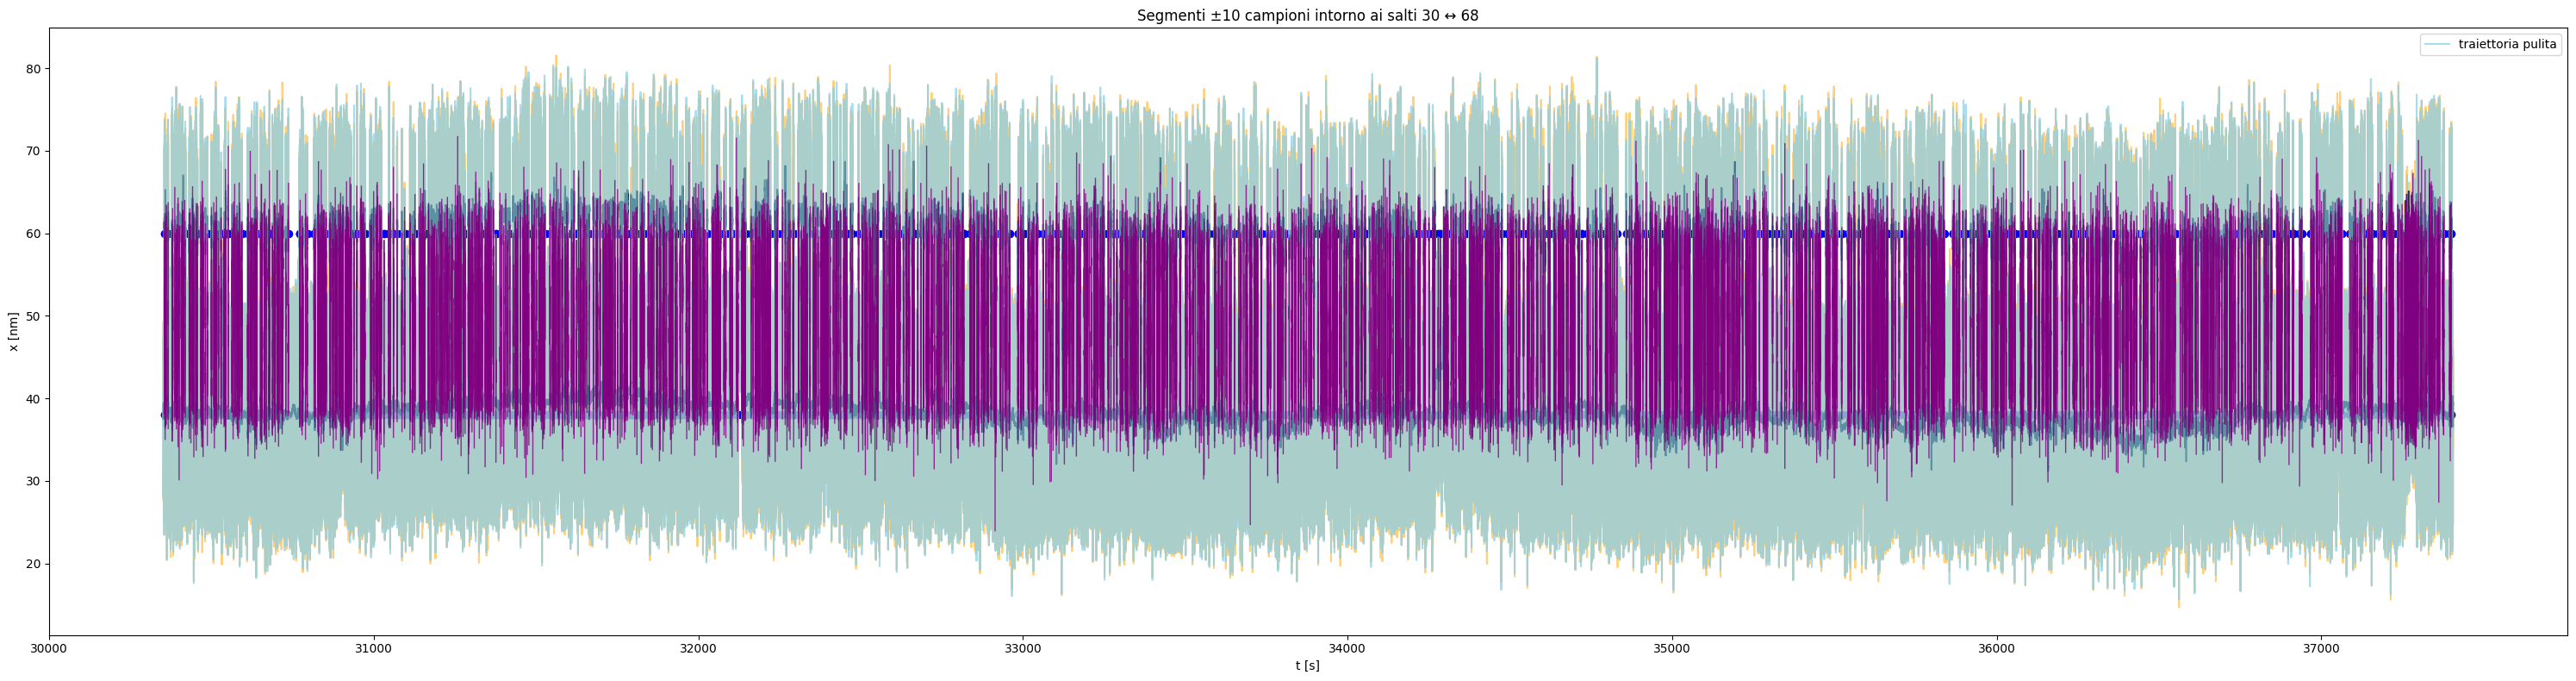

In [38]:
mask = np.full_like(x, np.nan)
mask[x < 39] = 38
mask[x > 59] = 60

start = 0 #3000
fine  = 7_818_823 #4_000#      # intervallo da visualizzare

t_win = t[start:fine]
x_win = x[start:fine]
mask_win  = mask[start:fine]


valid_idx   = np.where(~np.isnan(mask_win))[0]      # array di indici
valid_vals  = mask_win[valid_idx]                   # i loro valori (30/68)

change_pos  = np.where(valid_vals[1:] != valid_vals[:-1])[0] + 1

idx_from = valid_idx[change_pos - 1]    # ultimo indice del blocco corrente
idx_to   = valid_idx[change_pos]        # primo indice del blocco successivo


plt.figure(figsize=(30, 8))
plt.scatter(t_win[idx_to], mask_win[idx_to], c='red', s=35)
plt.scatter(t_win[idx_from], mask_win[idx_from], c='blue', s=35)
plt.plot(t_win, x[start:fine], color='orange', alpha=0.5)
x_detrend = np.full_like(x_win, np.nan)
start = 0



for i_from, i_to in zip(idx_from, idx_to):
    # plateau
    end = i_from
    seg = x_win[start:end+1]
    if len(seg)< 1_000:
        win = max(1, len(seg) // 4)
    else:       
        win = max(1, len(seg) // 10)

    drift = pd.Series(seg).rolling(win, center=True, min_periods=1).mean().values
    t_drift = t_win[start:start+len(drift)]
    plt.plot(t_drift, drift, color="black", alpha=1)
    delta = np.mean(seg) -  drift
    x_detrend[start:end+1] = seg + delta 


## transition
    seg_trans = x_win[end+1:i_to]
    if len(seg)< 1_000:
        win = max(1, len(seg) // 4)
    else:       
        win = max(1, len(seg) // 10)
    win_trans = win 
    drift_trans = pd.Series(seg_trans).rolling(win_trans, center=True, min_periods=1).mean().values
    delta_trans = np.mean(seg_trans) - drift_trans
    x_detrend[end+1:i_to] = seg_trans + delta_trans
    
    start = i_to

# ultimo blocco
if start < fine:
    seg = x_win[start:fine]
    if len(seg)< 1_000:
        win = max(1, len(seg) // 3)
    else:       
        win = max(1, len(seg) // 20)

    drift = pd.Series(seg).rolling(win, center=True, min_periods=1).mean().values
    t_drift = t_win[start:start+len(drift)]
    plt.plot(t_drift, drift, color='black', alpha=1)
    delta =  np.mean(seg) -  drift
    x_detrend[start:fine] = seg + delta

#plot traiettoria detrended finale
plt.plot(t_win, x_detrend, label="traiettoria pulita", c="skyblue",alpha=0.7)
plt.xlabel('t [s]')
plt.ylabel('x [nm]')
plt.title('Segmenti ±10 campioni intorno ai salti 30 ↔ 68')
plt.legend()
plt.tight_layout()


offset = 0                  

for i_from, i_to in zip(idx_from, idx_to):      
    i_start = max(i_from - offset, 0)         
    i_end   = min(i_to   + offset, fine-1)     
    plt.plot(t_win[i_start:i_end+1], x_win[i_start:i_end+1], color='purple', lw=1, alpha=.8)      

plt.xlabel('t [s]'); plt.ylabel('x [nm]'); plt.title('Segmenti ±10 campioni intorno ai salti 30 ↔ 68')
plt.show()

# print(f'Numero di transizioni rilevate: {len(idx_from)}')
# # idx_from  = ultimo indice del plateau corrente   (30 o 68)
# # idx_to    = primo indice del plateau successivo (68 o 30)

# # t_TP 
# for k, (i_from, i_to) in enumerate(zip(idx_from, idx_to), start=1):
#     print(f"Salto #{k:02d}:  from idx {i_from }  →  to idx {i_to}")

# Costruzione dati
data = []
for i, (i_from, i_to) in enumerate(zip(idx_from, idx_to)):
    dt = t_win[i_to] - t_win[i_from]
    transition_type = 'unfolding' if i % 2 == 0 else 'folding'
    data.append((i_from, i_to, dt, transition_type, t_win[i_from], t_win[i_to]))

df_transizioni = pd.DataFrame(data, columns=["start_idx", "end_idx", "duration", "type", "t_1", "t_2"])
df_transizioni.to_pickle("transizioni_real.pkl")


In [39]:

df = pd.read_pickle("transizioni_real.pkl")
df

,start_idx,end_idx,duration,type,t_1,t_2
0,3020,3030,0.008,unfolding,30355.115,30355.123
1,3844,3880,0.035,folding,30355.854,30355.889
2,5614,5635,0.023,unfolding,30357.422,30357.445
3,6185,6194,0.006,folding,30357.947,30357.953
4,6200,6204,0.004,unfolding,30357.959,30357.963
...,...,...,...,...,...,...
3901,7809866,7809879,0.008,folding,37397.031,37397.039
3902,7810138,7810145,0.004,unfolding,37397.277,37397.281
3903,7810612,7810644,0.028,folding,37397.699,37397.727
3904,7812403,7812412,0.004,unfolding,37399.348,37399.352


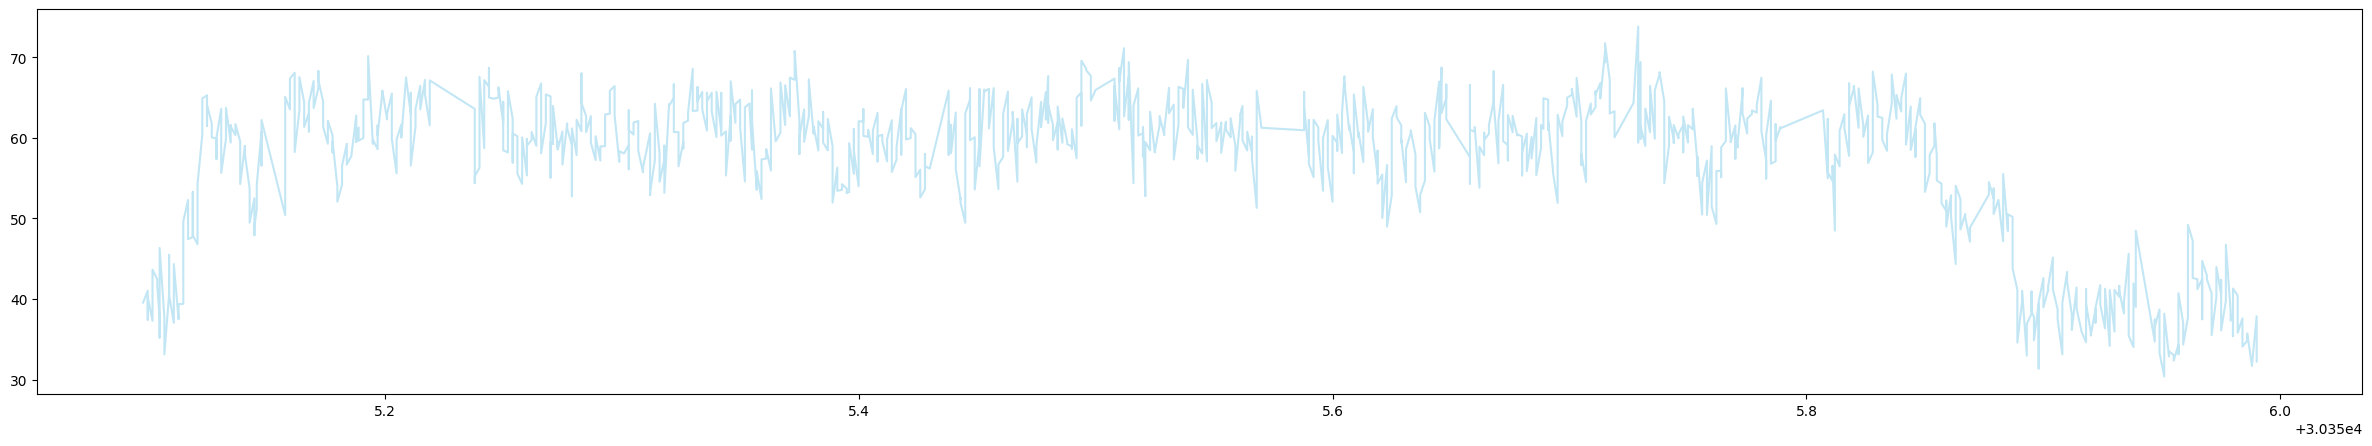

In [30]:
plt.figure(figsize=(30,5))
plt.plot(t_win, x_detrend, label="traiettoria pulita", c="skyblue",alpha=0.5)
plt.show()

X values of histogram peaks: [14.51 15.53 16.89 17.91 37.97 60.07 80.13 81.49]
X values of histogram peaks (cleaned): [16.21 17.23 17.91 37.97 59.73 60.75 77.75 79.45 80.13 81.15]


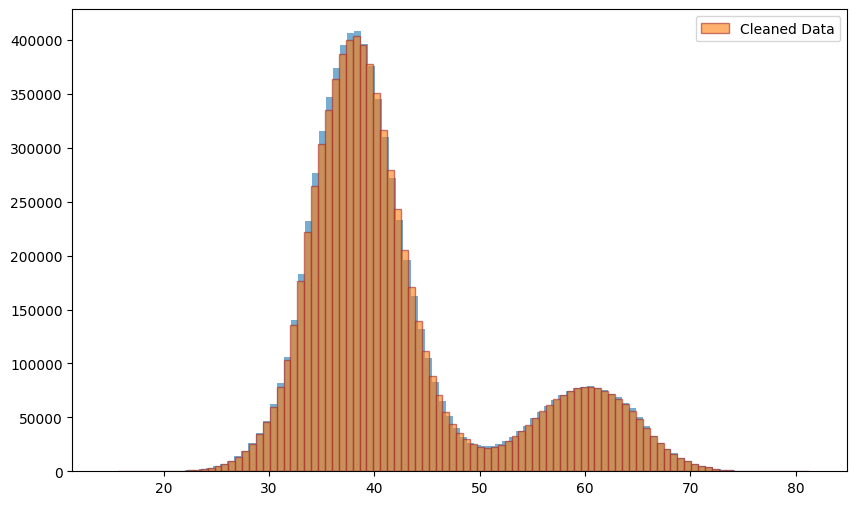

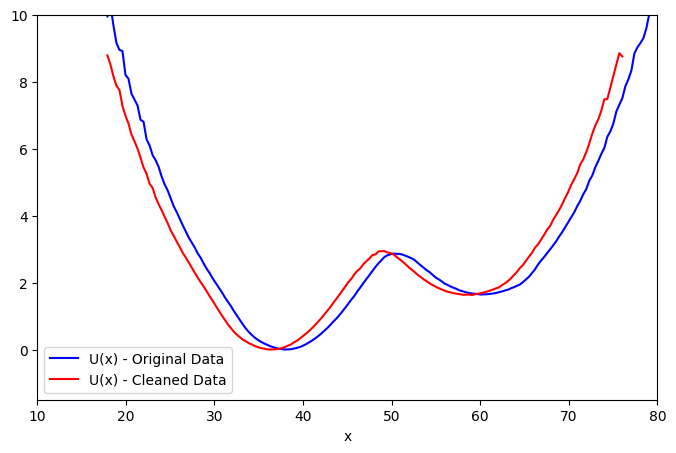

In [40]:

# removing global outliers
from scipy.signal import find_peaks
from scipy.stats import zscore

eb = np.linspace(14, 82, 201) #bins edges

plt.figure(figsize=(10, 6))
counts1, bin_edges = np.histogram(x_win, bins=eb, density=True)
bin_centers1 = (bin_edges[:-1] + bin_edges[1:]) / 2
peaks_indices, _ = find_peaks(counts1)
peak_x_values = bin_centers1[peaks_indices]
print("X values of histogram peaks:", peak_x_values)

from scipy.ndimage import gaussian_filter1d
counts2, bin_edges2 = np.histogram(x_detrend, bins=eb, density=True)

# Smooth dei counts prima del logaritmo
counts2_smooth = gaussian_filter1d(counts2, sigma=1.5)
U_2 = -np.log(counts2_smooth + 1e-10)

bin_centers2 = (bin_edges2[:-1] + bin_edges2[1:]) / 2
peaks_indices2, _ = find_peaks(counts2)
peak_x_values2 = bin_centers2[peaks_indices2]
print("X values of histogram peaks (cleaned):", peak_x_values2)

plt.hist(x_win, bins=100, alpha=0.6)
plt.hist(x_detrend, ec="brown", bins=100, alpha=0.6, label = "Cleaned Data") 
plt.legend(); plt.show()

U_1 = -np.log(counts1 + 1e-10)
U_2 = -np.log(counts2 + 1e-10)
U_1_shifted = U_1 - np.min(U_1)
U_2_shifted = U_2 - np.min(U_2)
U_2_shifted[counts2 < 1e-5] = np.nan  # Nasconde i punti dove non c'è statistica

x_peak1 = bin_centers1[peaks_indices[0]]
x_peak2 = bin_centers2[peaks_indices2[0]]

x_shift = x_peak1 - x_peak2
bin_centers2_aligned = bin_centers2 + x_shift

plt.figure(figsize=(8, 5))
plt.plot(bin_centers1, U_1_shifted, color='blue', label="U(x) - Original Data", linewidth=1.5)
plt.plot(bin_centers2_aligned, U_2_shifted, color='red', label="U(x) - Cleaned Data", linewidth=1.5)
plt.xlabel('x'); plt.xlim(10,80); plt.ylim(-1.5,10)
plt.legend()


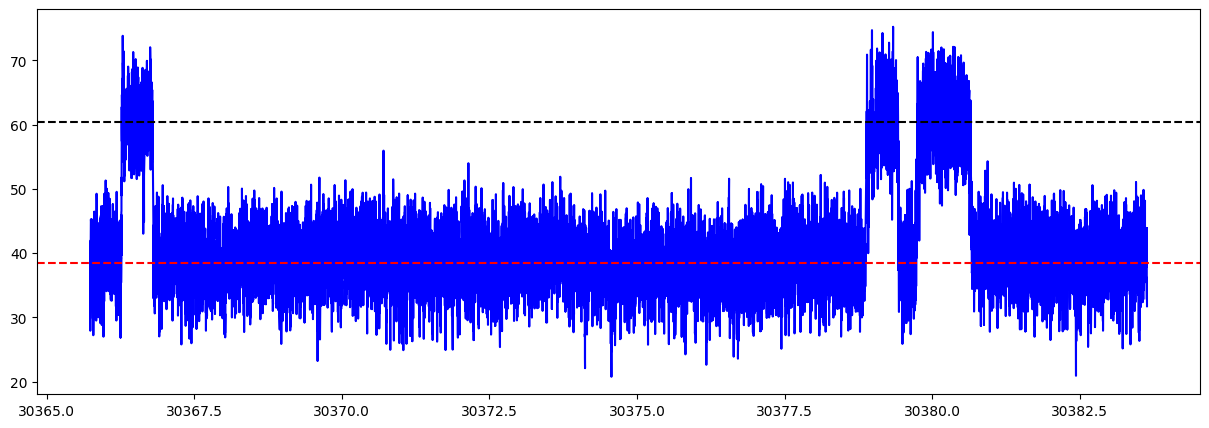

In [41]:
plt.figure(figsize=(15, 5))

plt.plot(t[15_000:35_000], x[15_000:35_000], color='blue')
xm = np.mean(x[700_000:990_000])
# plt.axhline(y=xm, color='red', linestyle='--')
plt.axhline(y=peaks[0], color='red', linestyle='--')
plt.axhline(y=peaks[1], color='black', linestyle='--')

In [42]:
print (np.max(x_win), np.min(x_win))
print (np.max(x_detrend), np.min(x_detrend))

81.547539 14.658421
81.21130873053987 15.6297641688063


In [43]:
# DECONVOLUTION

noise = np.loadtxt('beads_noise.txt', skiprows=1)  # Cambia con il tuo nome file
z_data = noise[:, 0]  # Colonna Z (nm)
t_data = noise[:, 1]  # Colonna Tempo (sec)

kernel, bins = np.histogram(z_data, bins=200, density=True)
counts2, bin_edges2 = np.histogram(x_detrend, bins=200, density=True)

def jansson_deconvolution(observed, kernel, iterations=700, alpha=0.02):
    from scipy.signal import fftconvolve

    kernel = kernel / np.sum(kernel)
    estimate = np.copy(observed).astype(np.float64)

    for _ in range(iterations):
        reconvolved = fftconvolve(estimate, kernel, mode='same')
        # usa una regolarizzazione minima per evitare annullamenti
        correction = observed - reconvolved
        update = alpha * correction * estimate
        estimate += update
        estimate[estimate < 0] = 0  # forza positività

    return estimate

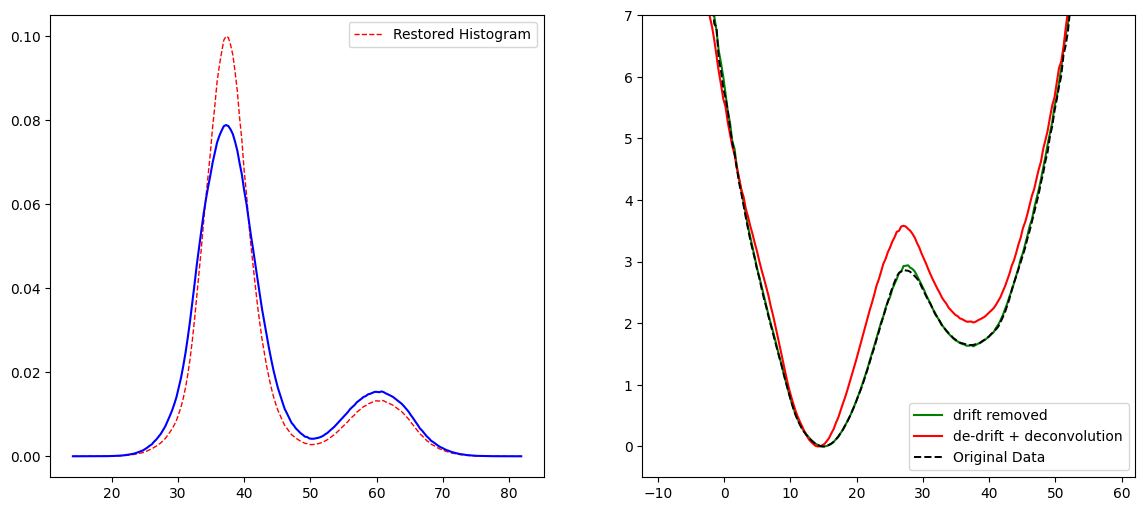

In [49]:
restored = jansson_deconvolution(counts2, kernel,  iterations=700, alpha=0.02)  #counts2: data w/out drift ## restored: no drift + deconvlution  
restored /= np.sum(restored) * (bin_centers2[1] - bin_centers2[0]) #!!!!!!!!!!!!!!!! RI NORMALIZZA 

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(bin_centers2, restored, label="Restored Histogram", lw=1, linestyle='--', c="r")
plt.plot(bin_centers2, counts2, c="b")
plt.legend()

# recovering U(x)
U_obs  = U_2_shifted
U_dec = - np.log(restored + 1e-10)
shift = bin_centers2[np.argmin(U_obs)] - bin_centers2[np.argmin(U_dec)]
bin_centers2_shifted = bin_centers2 + shift
U_dec_shifted = U_dec - np.min(U_dec)


plt.subplot(1, 2, 2)
plt.plot(bin_centers2_shifted, U_obs, c= "green", label = "drift removed")
plt.plot(bin_centers2_shifted, U_dec_shifted, c= "r", label="de-drift + deconvolution")
plt.plot(bin_centers2_shifted, U_1_shifted, linestyle="--", lw = 1.4, alpha = 1, c="black", label = "Original Data")
plt.ylim(-0.5, 7)
plt.legend()
plt.show()


0.012000000002444722 0.01744342037895222
0.012000000002444722 0.01799795186895575


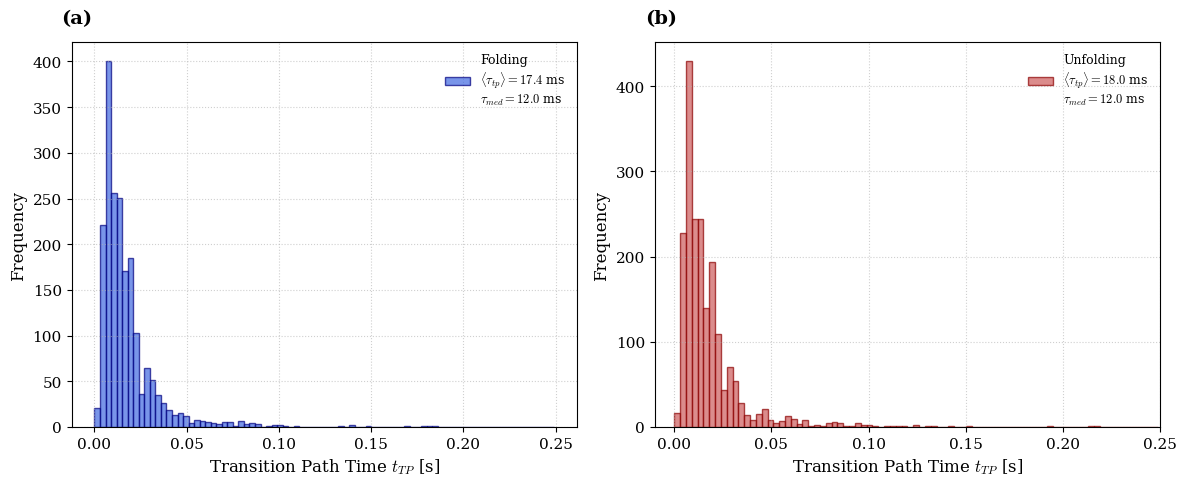

In [57]:
## t_TP

df = pd.read_pickle("transizioni_real.pkl")

tp_fold = df[df["type"] == "folding"]["duration"]
tp_unf = df[df["type"] == "unfolding"]["duration"]
print(np.median(tp_fold), np.mean(tp_fold))
print(np.median(tp_unf), np.mean(tp_unf))

i

# Configurazione stile accademico
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'legend.fontsize': 9,
    'mathtext.fontset': 'cm'
})

def plot_tp_side_by_side(tp_fold, tp_unf):
    # Creazione della figura: 1 riga, 2 colonne
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    bins = np.arange(0, 0.25, 0.003)

    # --- Pannello (a): Folding ---
    m_f, med_f = np.mean(tp_fold) * 1e3, np.median(tp_fold) * 1e3
    label_f = f"Folding\n$\\langle \\tau_{{tp}} \\rangle = {m_f:.1f}$ ms\n$\\tau_{{med}} = {med_f:.1f}$ ms"
    
    ax1.hist(tp_fold, bins=bins, alpha=0.7, color='royalblue', edgecolor='navy', label=label_f)
    ax1.set_xlabel("Transition Path Time $t_{TP}$ [s]")
    ax1.set_ylabel("Frequency")
    ax1.legend(loc='upper right', frameon=False)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.text(-0.02, 1.05, "(a)", transform=ax1.transAxes, fontsize=14, fontweight='bold')

    # --- Pannello (b): Unfolding ---
    m_u, med_u = np.mean(tp_unf) * 1e3, np.median(tp_unf) * 1e3
    label_u = f"Unfolding\n$\\langle \\tau_{{tp}} \\rangle = {m_u:.1f}$ ms\n$\\tau_{{med}} = {med_u:.1f}$ ms"
    
    ax2.hist(tp_unf, bins=bins, alpha=0.7, color='indianred', edgecolor='darkred', label=label_u)
    ax2.set_xlabel("Transition Path Time $t_{TP}$ [s]")
    ax2.set_ylabel("Frequency")
    ax2.set_xlim(-0.01, 0.25)
    ax2.legend(loc='upper right', frameon=False)
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.text(-0.02, 1.05, "(b)", transform=ax2.transAxes, fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.savefig("TP_distribution.pdf")
    plt.show()

# Esecuzione
plot_tp_side_by_side(tp_fold, tp_unf)


U_max: 3.5821504481794473
left_min: 0.0
right_min: 2.011997848205651
dG_fold: 1.5701525999737962
dG_unfold: 3.5821504481794473
beta: 0.24330900243309
gamma: 0.577
dG_fold: 1.5701525999737962
kappa_b: 0.14240135532328793
tp_mean_F: 0.01744342037895222
Numeratore arg log: 1.360560795141663
Diffusion coeff _fold: 2848.115942911354 Diffusion coeff_unfold: 4083.023300316318


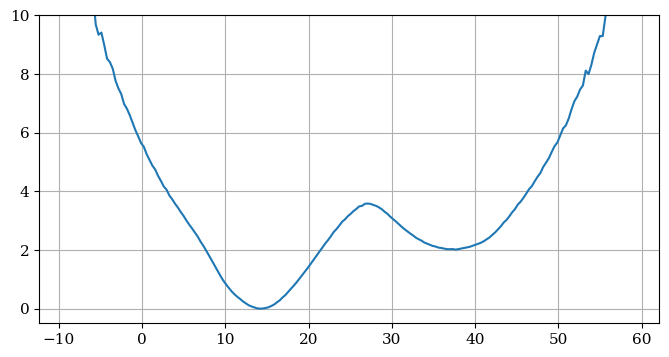

In [58]:
def D_coeff(tp_mean_F, tp_mean_U, U, x, beta=1/4.11, gamma=0.577):
 
    from scipy.ndimage import gaussian_filter1d

    edge_fraction = 0.2
    N = len(U)
    start = int(N * edge_fraction)
    end = int(N * (1 - edge_fraction))
    mask = np.zeros_like(U, dtype=bool)
    mask[start:end] = True

    U_masked = U[mask]
    x_masked = x[mask]

    max_idx_masked = np.argmax(U_masked)
    max_idx = np.arange(len(U))[mask][max_idx_masked]  # mappa sull’indice originale
    U_max = U[max_idx]

    left_min = np.min(U[start:max_idx])
    right_min = np.min(U[max_idx:end])

    plt.figure(figsize=(8, 4))
    plt.plot(x, U, label="U(x)"); plt.grid(True); plt.ylim(-0.5, 10)

    # left_min_idx = start + np.argmin(U[start:max_idx])
    # right_min_idx = max_idx + np.argmin(U[max_idx:end])

    dG_fold = U_max - right_min
    dG_unfold = U_max - left_min
    print("U_max:", U_max)
    print("left_min:", left_min)
    print("right_min:", right_min)
    print("dG_fold:", dG_fold)
    print("dG_unfold:", dG_unfold)

    # --- Curvatura barriera (kappa_b) ---
    U_smooth = gaussian_filter1d(U_masked, sigma=2.5)

    dx = x_masked[1] - x_masked[0]
    d2U_dx2 = np.gradient(np.gradient(U_smooth, dx), dx)

    max_idx_smooth = np.argmax(U_smooth)
    max_idx = np.arange(len(U))[mask][max_idx_smooth]  # coerente con curvatura

    kappa_b =np.abs(np.mean(d2U_dx2[max_idx_smooth - 1:max_idx_smooth + 2]))

    # --- Coefficienti D ---
    D_fold = np.log(2 * np.exp(gamma) * beta * dG_fold*4.11) / (beta * kappa_b * tp_mean_F)
    D_unfold = np.log(2 * np.exp(gamma) * beta * dG_unfold*4.11) / (beta * kappa_b * tp_mean_U)
    
    print("beta:", beta)
    print("gamma:", gamma)
    print("dG_fold:", dG_fold)
    print("kappa_b:", kappa_b)
    print("tp_mean_F:", tp_mean_F)
    print("Numeratore arg log:", 2 * np.exp(gamma) * beta * dG_fold)


    return ( D_fold, D_unfold, kappa_b, dG_fold, dG_unfold)



D_fold, D_unfold, kappa_b, dG_fold, dG_unfold = D_coeff(np.mean(tp_fold), np.mean(tp_unf), U_dec_shifted, bin_centers2_shifted)
print ("Diffusion coeff _fold:", D_fold, "Diffusion coeff_unfold:", D_unfold)

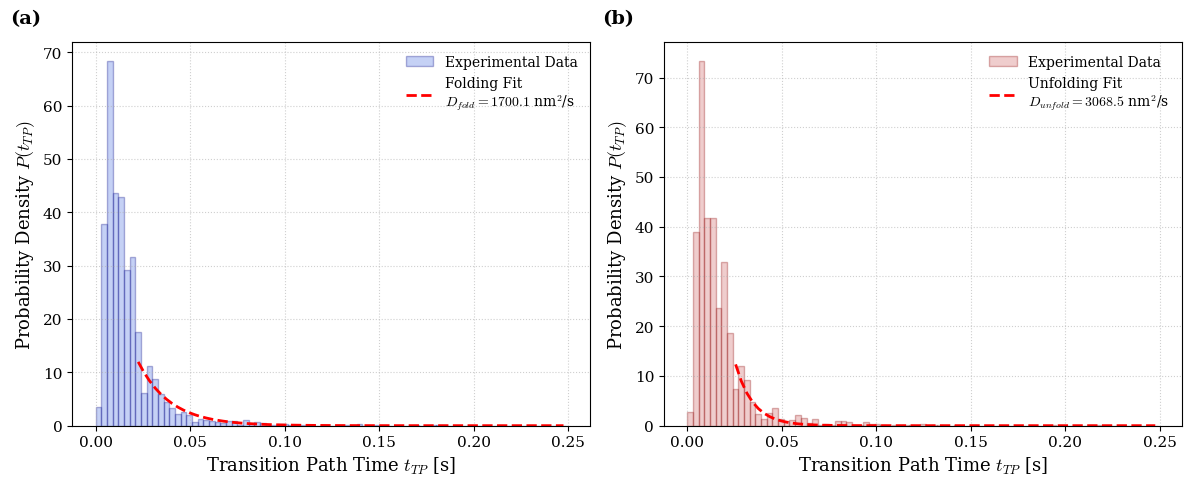

In [61]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize_scalar

# Configurazione stile "Thesis-ready"
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 13,
    'legend.fontsize': 10,
    'mathtext.fontset': 'cm'
})

def exp_decay(t, D, kappa_b, deltaG, beta=1/4.11):
    omega_k = beta * D * np.abs(kappa_b)
    A = 2 * omega_k * beta * deltaG
    return A * np.exp(-omega_k * t)

# Creazione figura 1 riga, 2 colonne
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
bins = np.arange(0, 0.25, 0.003)

# --- PANEL (a): Folding ---
hist_f, edges_f = np.histogram(tp_fold, bins=bins, density=True)
centers_f = (edges_f[:-1] + edges_f[1:]) / 2
mask_f = centers_f > 0.02

res_f = minimize_scalar(lambda D: np.sum((exp_decay(centers_f[mask_f], D, kappa_b, dG_fold) - hist_f[mask_f])**2), 
                        bounds=(100, 10000), method='bounded')
D_f = res_f.x

ax1.hist(tp_fold, bins=bins, density=True, color='royalblue', alpha=0.3, edgecolor='navy', label='Experimental Data')
ax1.plot(centers_f[mask_f], exp_decay(centers_f[mask_f], D_f, kappa_b, dG_fold), 'r--', linewidth=2,
         label=f'Folding Fit\n$D_{{fold}} = {D_f:.1f}$ nm$^2$/s')
ax1.set_xlabel("Transition Path Time $t_{TP}$ [s]")
ax1.set_ylabel("Probability Density $P(t_{TP})$")
ax1.legend(frameon=False)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.text(-0.12, 1.05, "(a)", transform=ax1.transAxes, fontsize=14, fontweight='bold')

# --- PANEL (b): Unfolding ---
hist_u, edges_u = np.histogram(tp_unf, bins=bins, density=True)
centers_u = (edges_u[:-1] + edges_u[1:]) / 2
mask_u = centers_u > 0.025

res_u = minimize_scalar(lambda D: np.sum((exp_decay(centers_u[mask_u], D, kappa_b, dG_unfold) - hist_u[mask_u])**2), 
                        bounds=(100, 10000), method='bounded')
D_u = res_u.x

ax2.hist(tp_unf, bins=bins, density=True, color='indianred', alpha=0.3, edgecolor='darkred', label='Experimental Data')
ax2.plot(centers_u[mask_u], exp_decay(centers_u[mask_u], D_u, kappa_b, dG_unfold), 'r--', linewidth=2,
         label=f'Unfolding Fit\n$D_{{unfold}} = {D_u:.1f}$ nm$^2$/s')
ax2.set_xlabel("Transition Path Time $t_{TP}$ [s]")
ax2.set_ylabel("Probability Density $P(t_{TP})$")
ax2.legend(frameon=False)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.text(-0.12, 1.05, "(b)", transform=ax2.transAxes, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("TP_Destimation.pdf")
plt.show()